# 02 — Exploratory Data Analysis
WBC Classification · Bodzas et al. Dataset

Goals:
- Verify the split worked correctly
- Visualise class distribution and imbalance
- Inspect sample images per class
- Compute pixel-level statistics (mean/std per channel) for sanity-check

In [6]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from tqdm import tqdm

from dataset import CLASSES, IMG_SIZE

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR  = Path('../data/processed')
EDA_DIR   = Path('../EDA')
EDA_DIR.mkdir(exist_ok=True)

SPLITS = ['train', 'val', 'test']

## 1 · Class Distribution per Split

In [7]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

counts = {split: {} for split in SPLITS}

for split in SPLITS:
    for cls in CLASSES:
        cls_dir = DATA_DIR / split / cls
        n = sum(1 for p in cls_dir.glob('*') if p.suffix.lower() in IMG_EXTS) if cls_dir.exists() else 0
        counts[split][cls] = n

df_counts = pd.DataFrame(counts)
df_counts['total'] = df_counts.sum(axis=1)
display(df_counts)

,train,val,test,total
Basophile,613,204,206,1023
Eosinophile,610,203,204,1017
Lymphoblast,1534,511,512,2557
Lymphocyte,1827,609,610,3046
Monocyte,1224,408,408,2040
Myeloblast,1520,506,508,2534
Neutrophile_Band,59,19,21,99
Neutrophile_Segment,1920,640,641,3201
Normoblast,306,102,102,510


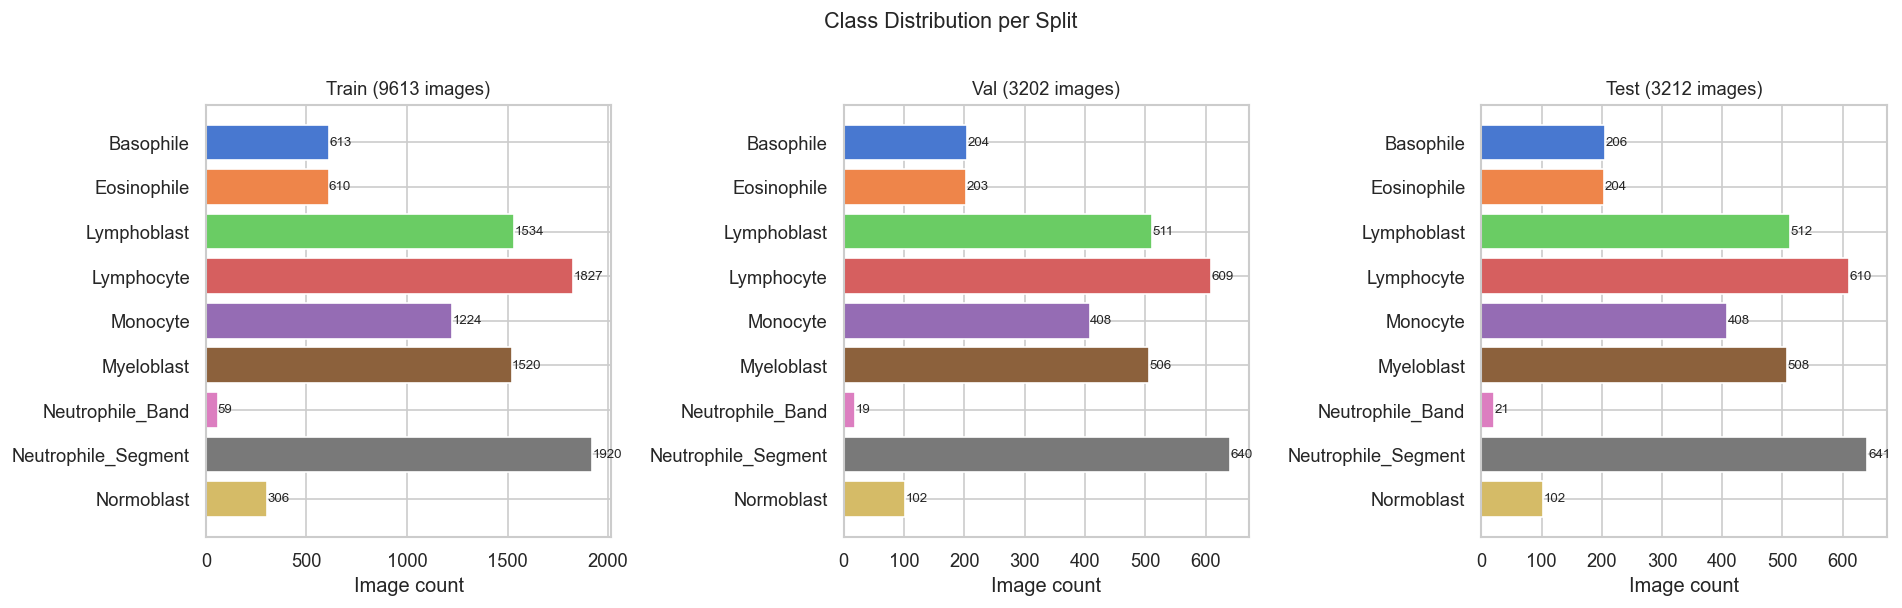

Saved → EDA/class_distribution.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

colors = sns.color_palette('muted', len(CLASSES))

for ax, split in zip(axes, SPLITS):
    vals = [counts[split][cls] for cls in CLASSES]
    bars = ax.barh(CLASSES, vals, color=colors)
    ax.set_title(f'{split.capitalize()} ({sum(vals)} images)', fontsize=11)
    ax.set_xlabel('Image count')
    for bar, v in zip(bars, vals):
        ax.text(v + 1, bar.get_y() + bar.get_height()/2, str(v),
                va='center', fontsize=8)
    ax.invert_yaxis()

plt.suptitle('Class Distribution per Split', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / 'class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved → EDA/class_distribution.png')

## 2 · Class Imbalance Ratio
Imbalance ratio = max_class_count / min_class_count in the train set.
High ratios (>5×) suggest class weighting or oversampling is needed.

In [9]:
train_counts = [counts['train'][cls] for cls in CLASSES]
max_c, min_c = max(train_counts), min(train_counts)
print(f'Max class : {CLASSES[train_counts.index(max_c)]:25s} → {max_c}')
print(f'Min class : {CLASSES[train_counts.index(min_c)]:25s} → {min_c}')
print(f'Imbalance ratio: {max_c/min_c:.1f}×')

# If ratio > 5, class weights will be important — see dataset.get_class_weights()

Max class : Neutrophile_Segment       → 1920
Min class : Neutrophile_Band          → 59
Imbalance ratio: 32.5×


## 3 · Sample Image Grid per Class

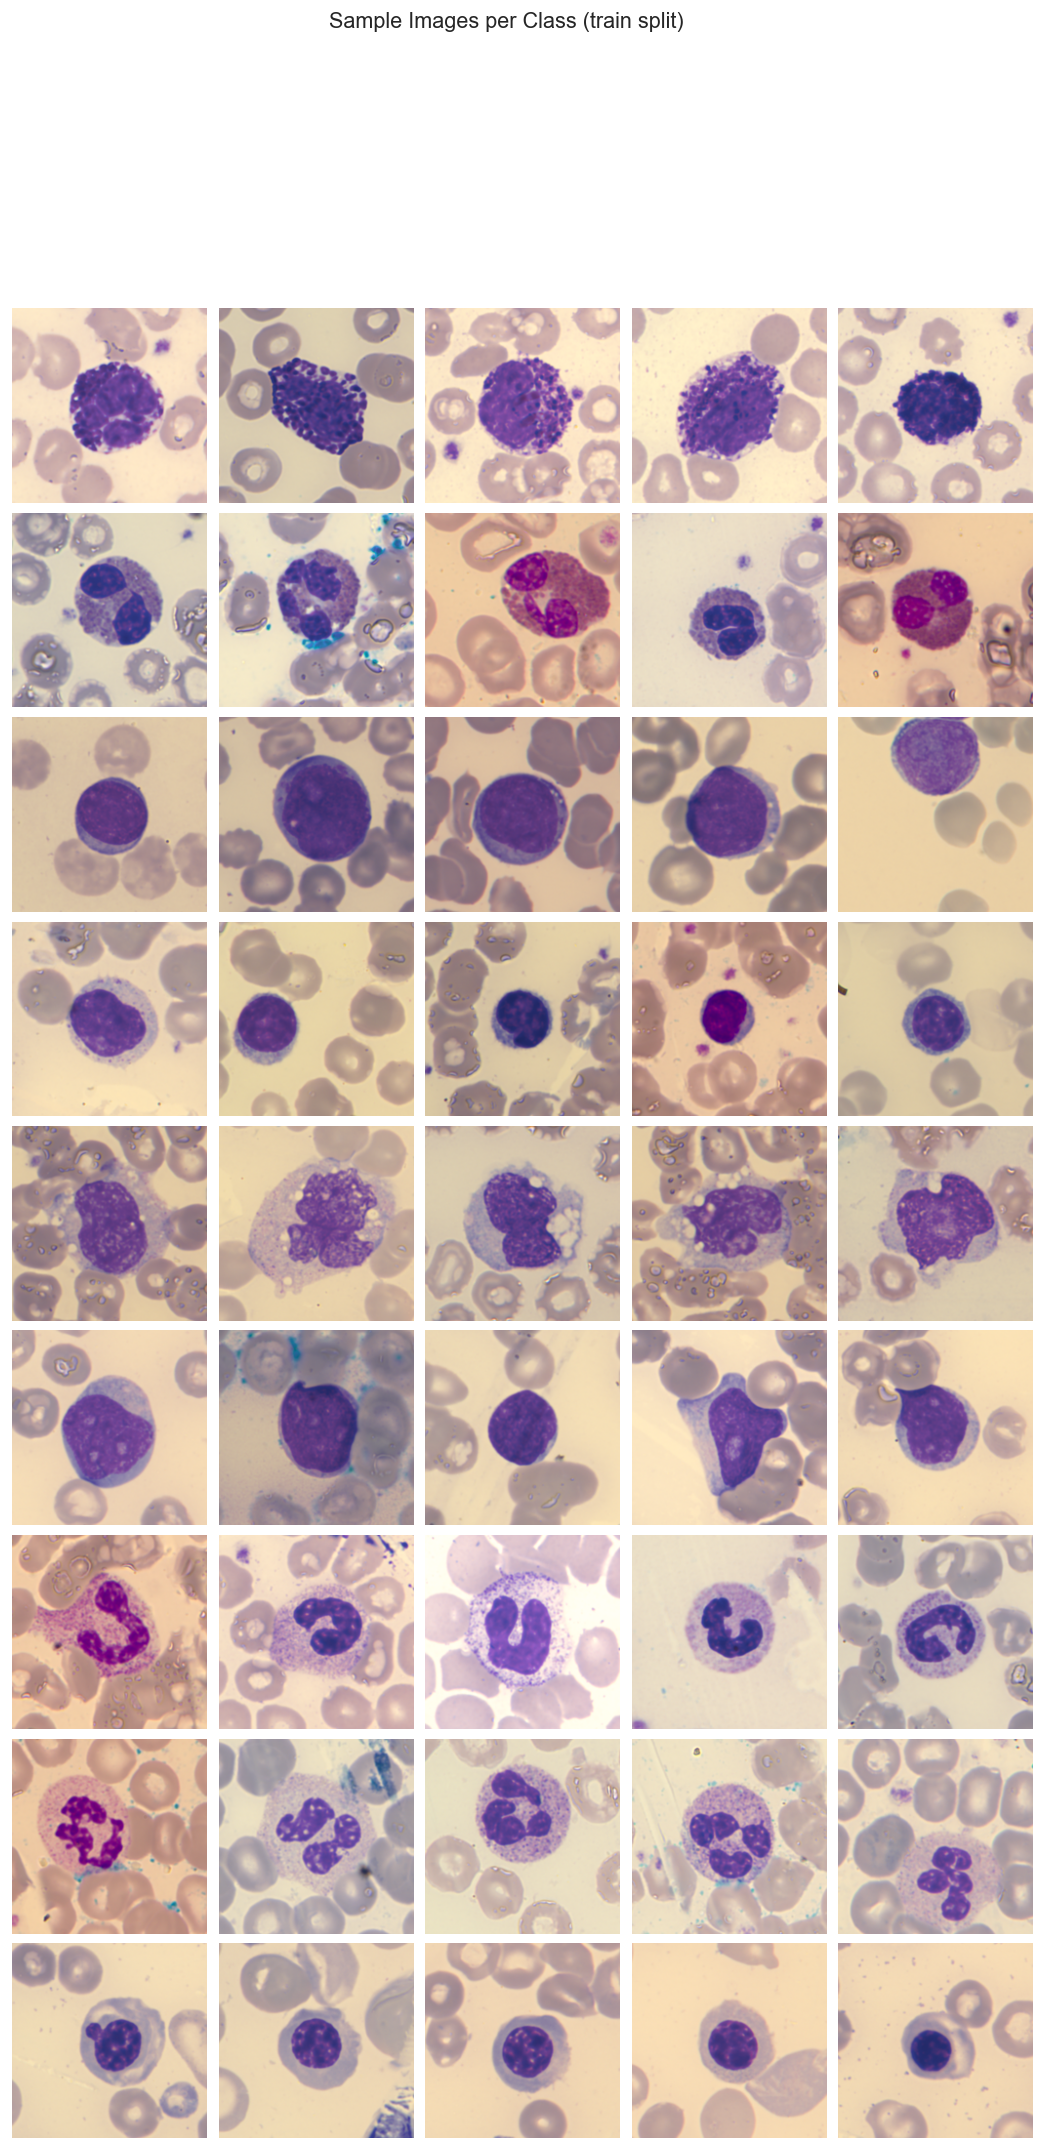

Saved → EDA/sample_grid.png


In [10]:
N_SAMPLES = 5  # images per class

fig = plt.figure(figsize=(N_SAMPLES * 2.2, len(CLASSES) * 2.2))
gs  = gridspec.GridSpec(len(CLASSES), N_SAMPLES, figure=fig, hspace=0.05, wspace=0.05)

import random
random.seed(42)

for row, cls in enumerate(CLASSES):
    cls_dir   = DATA_DIR / 'train' / cls
    img_paths = [p for p in cls_dir.glob('*') if p.suffix.lower() in IMG_EXTS] if cls_dir.exists() else []
    samples   = random.sample(img_paths, min(N_SAMPLES, len(img_paths)))

    for col, img_path in enumerate(samples):
        ax = fig.add_subplot(gs[row, col])
        img = Image.open(img_path).resize((200, 200))
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, fontsize=9, rotation=0, labelpad=80, va='center')

plt.suptitle('Sample Images per Class (train split)', fontsize=13, y=1.005)
plt.savefig(EDA_DIR / 'sample_grid.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved → EDA/sample_grid.png')

## 4 · Pixel Statistics (mean & std per RGB channel)
Run on a random sample of 500 train images. Used to verify preprocessing.

In [11]:
all_paths = []
for cls in CLASSES:
    cls_dir = DATA_DIR / 'train' / cls
    if cls_dir.exists():
        all_paths += [p for p in cls_dir.glob('*') if p.suffix.lower() in IMG_EXTS]

random.seed(0)
sample_paths = random.sample(all_paths, min(500, len(all_paths)))

means, stds = [], []
for p in tqdm(sample_paths, desc='Computing pixel stats'):
    img = np.array(Image.open(p).resize((IMG_SIZE, IMG_SIZE)).convert('RGB'), dtype=np.float32)
    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

mean_rgb = np.mean(means, axis=0)
std_rgb  = np.mean(stds,  axis=0)

pixel_stats = pd.DataFrame({
    'channel': ['R', 'G', 'B'],
    'mean':    mean_rgb,
    'std':     std_rgb,
})
pixel_stats.to_csv(EDA_DIR / 'pixel_stats.csv', index=False)
display(pixel_stats)
print('Saved → EDA/pixel_stats.csv')
print()
print('Note: EfficientNetB3 uses include_preprocessing=True, so raw [0,255]')
print('pixel values are correct — no manual normalisation needed.')

Computing pixel stats: 100%|█████████████████████████████████████████████████████████| 500/500 [00:11<00:00, 42.31it/s]


,channel,mean,std
0,R,192.990143,41.822830
1,G,168.518723,45.342209
2,B,161.904541,16.068634


Saved → EDA/pixel_stats.csv

Note: EfficientNetB3 uses include_preprocessing=True, so raw [0,255]
pixel values are correct — no manual normalisation needed.


## 5 · Image Size Verification

In [12]:
size_counter = Counter()
for p in tqdm(random.sample(all_paths, min(200, len(all_paths))), desc='Checking sizes'):
    with Image.open(p) as img:
        size_counter[img.size] += 1

print('Image sizes found (W×H : count):')
for size, cnt in size_counter.most_common(10):
    print(f'  {size[0]}×{size[1]} : {cnt}')

Checking sizes: 100%|████████████████████████████████████████████████████████████████| 200/200 [00:06<00:00, 31.42it/s]

Image sizes found (W×H : count):
  1200×1200 : 200
